# Trabajo Práctico N°3: Redes Neuronales

In [1]:
print('Clonando el repositorio de Git...')
!git clone https://github.com/aleorozcol/Orozco_Alejandro_TP3.git
print('Repositorio clonado con éxito. Ahora puedes acceder a los archivos en la carpeta Orozco_Alejandro_TP3.')

Clonando el repositorio de Git...
Cloning into 'Orozco_Alejandro_TP3'...
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 60 (delta 20), reused 51 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (60/60), 2.19 MiB | 22.16 MiB/s, done.
Resolving deltas: 100% (20/20), done.
Repositorio clonado con éxito. Ahora puedes acceder a los archivos en la carpeta Orozco_Alejandro_TP3.


In [2]:
import sys
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cupy as cp
import torch
import importlib

from google.colab import drive
drive.mount('/content/drive')

# Define la ruta al directorio del repositorio Git clonado
REPO_DIR = '/content/Orozco_Alejandro_TP3/src'

# Asegura que el directorio del repositorio esté en sys.path para importaciones directas
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
    print(f"'{REPO_DIR}' añadido a sys.path.")

# Enlace simbólico 'src' para los imports internos del repositorio
if os.path.exists('src'):
    if os.path.islink('src') and os.readlink('src') != REPO_DIR:
        os.unlink('src')
        os.symlink(REPO_DIR, 'src')
        print("Enlace simbólico 'src' actualizado.")
elif not os.path.exists('src'):
    os.symlink(REPO_DIR, 'src')
    print("Enlace simbólico 'src' creado.")

# --- Importación de módulos del repositorio con importlib ---
try:
    simple = importlib.import_module('MLP_simple')
    MLP = simple.MLP
    advanced = importlib.import_module('MLP_advanced')
    metrics = importlib.import_module('metrics')
    grid_search_ = importlib.import_module('grid_search')
    pytorch = importlib.import_module('pytorch')
    utils = importlib.import_module('utils')
    data_split = importlib.import_module('data_splitting')
    print("Módulos principales del repositorio importados con éxito con importlib.")
except ImportError as e:
    print(f"Error importando módulos principales: {e}")

# Módulos opcionales
for mod_name in ['preprocessing', 'utils', 'data_splitting']:
    try:
        importlib.import_module(mod_name)
    except ImportError:
        pass

print("Módulos opcionales procesados.")

Mounted at /content/drive
'/content/Orozco_Alejandro_TP3/src' añadido a sys.path.
Enlace simbólico 'src' creado.
Módulos principales del repositorio importados con éxito con importlib.
Módulos opcionales procesados.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Análisis y Preprocesamiento de Datos

In [4]:
X_images = np.load("X_images.npy")
y_images = np.load("y_images.npy")
print(f"Datos cargados: X_images {X_images.shape}, y_images {y_images.shape}")

Datos cargados: X_images (809555, 28, 28), y_images (809555,)


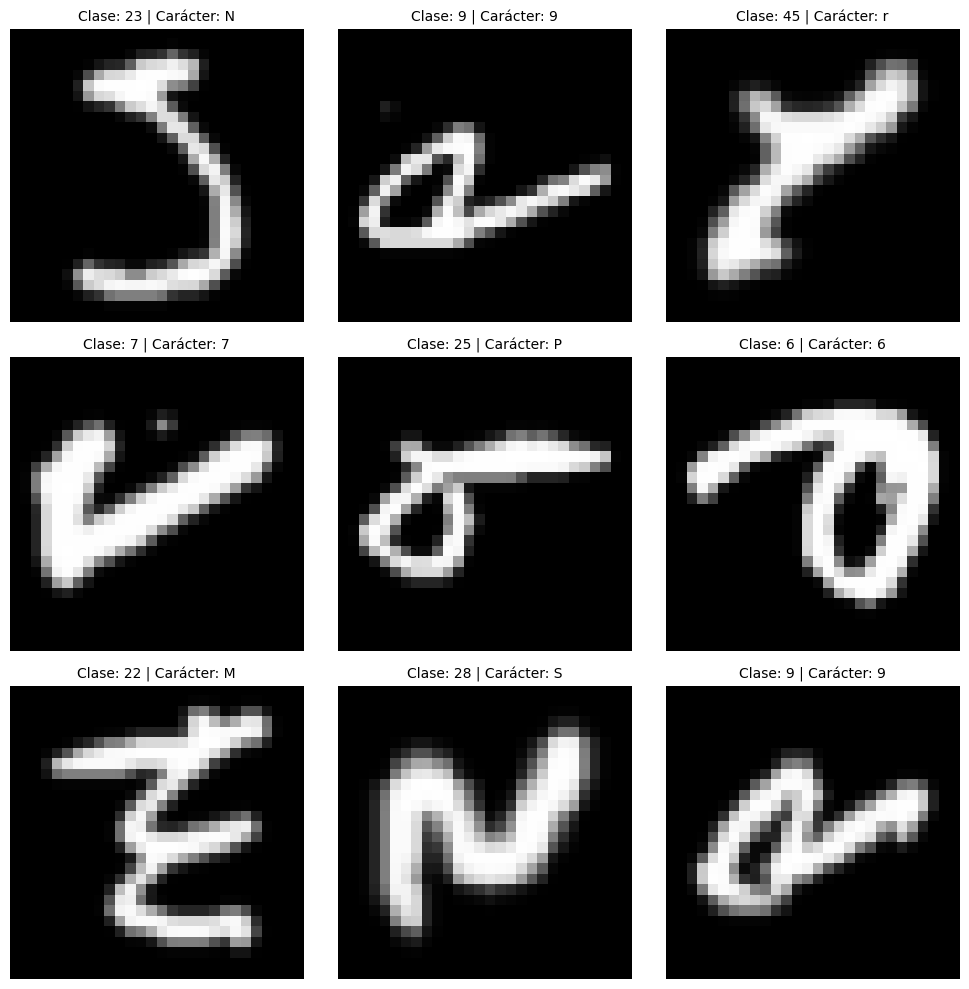

In [6]:
utils.plot_random_emnist_samples(X_images, y_images, n_samples=9)

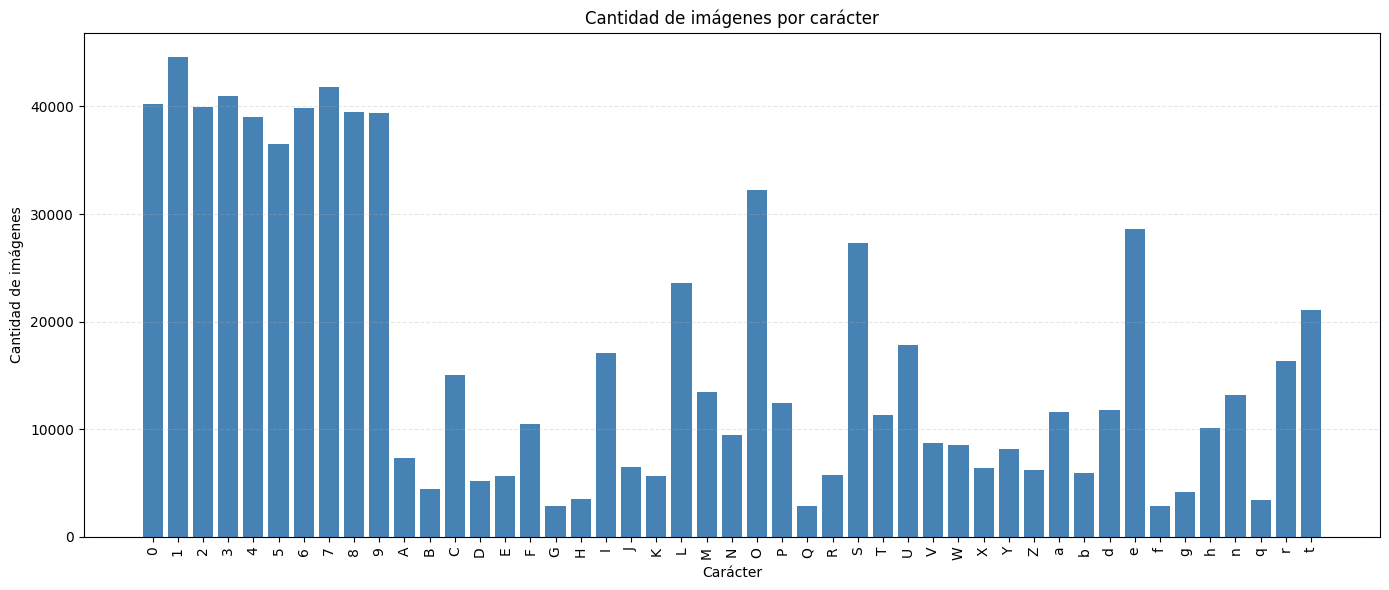

In [7]:
utils.plot_emnist_character_distribution(y_images)

In [8]:
X_train_norm, y_train, X_val_norm, y_val, X_test_norm, y_test = data_split.split_train_val_test_and_normalize(X_images, y_images, seed=42)

print(f"Tamaño Train: {X_train_norm.shape[0]} muestras")
print(f"Tamaño Validación: {X_val_norm.shape[0]} muestras")
print(f"Tamaño Test: {X_test_norm.shape[0]} muestras")
print(f"Rango de datos normalizados: Min={X_train_norm.min()}, Max={X_train_norm.max()}")

Tamaño Train: 566688 muestras
Tamaño Validación: 121433 muestras
Tamaño Test: 121434 muestras
Rango de datos normalizados: Min=0.0, Max=1.0


## 2. Implementación y Entrenamiento de una Red Neuronal Básica

In [11]:
# Aplanamos las imágenes. La red MLP espera vectores 1D como entrada,
# por lo que pasamos de (N, 28, 28) a (N, 784)
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_val_flat = X_val_norm.reshape(X_val_norm.shape[0], -1)

In [12]:
# Entrada: 784 nodos (28x28)
# Capas ocultas: 128 y 64 nodos
# Salida: 47 nodos (clases de EMNIST)
architecture_M0 = [784, 128, 64, 47]

M0 = MLP(architecture_M0)

EPOCHS = 100
LEARNING_RATE = 0.1

print("Iniciando entrenamiento del modelo M0...")
train_loss_M0, val_loss_M0 = M0.train(X_train_flat, y_train, X_val_flat, y_val, EPOCHS, LEARNING_RATE)

Iniciando entrenamiento del modelo M0...
Época 000 | Train Loss: 4.0317 | Val Loss: 3.8537
Época 010 | Train Loss: 3.3433 | Val Loss: 3.3002
Época 020 | Train Loss: 2.9347 | Val Loss: 2.9024
Época 030 | Train Loss: 2.6087 | Val Loss: 2.5840
Época 040 | Train Loss: 2.3495 | Val Loss: 2.3315
Época 050 | Train Loss: 2.1440 | Val Loss: 2.1312
Época 060 | Train Loss: 1.9790 | Val Loss: 1.9704
Época 070 | Train Loss: 1.8470 | Val Loss: 1.8414
Época 080 | Train Loss: 1.7401 | Val Loss: 1.7367
Época 090 | Train Loss: 1.6524 | Val Loss: 1.6506
Época 099 | Train Loss: 1.6812 | Val Loss: 1.6695


## Explicación de la implementación del Punto 2

La red neuronal usada en este punto es un **MLP (Multilayer Perceptron)** totalmente conectado. En el notebook se crea con `arquitectura_M0 = [784, 128, 64, 47]`, y eso significa lo siguiente:

- **784 nodos de entrada**: cada imagen de 28x28 píxeles se aplana con `reshape` para transformarse en un vector de 784 valores.
- **2 capas ocultas**: la primera con 128 neuronas y la segunda con 64 neuronas.
- **47 nodos de salida**: uno por cada clase del dataset EMNIST.

### 1. Entrada de los datos
Antes de entrenar, las imágenes se normalizan y luego se convierten de matriz a vector. Esto permite que la red reciba una fila por muestra, algo necesario para trabajar con capas densas. Cada vector representa la imagen completa en una sola dimensión.

### 2. Inicialización de pesos y sesgos
En la clase `MLP`, cada capa aprende dos parámetros:

- **Pesos (`W`)**: controlan la fuerza de la conexión entre neuronas.
- **Sesgos (`b`)**: permiten desplazar la activación de cada neurona.

Los pesos se inicializan con una estrategia tipo **He initialization**, que ayuda a mantener estables las activaciones al comienzo del entrenamiento y evita que la señal se apague o explote en redes con ReLU.

### 3. Forward pass
En cada capa oculta la red calcula:

$$Z = A \cdot W + b$$

Luego aplica la función **ReLU**:

$$\mathrm{ReLU}(Z) = \max(0, Z)$$

Esto introduce no linealidad, lo que permite que la red aprenda patrones complejos. Si no se usara una activación como ReLU, la red se comportaría como una transformación lineal apilada y perdería capacidad de representación.

### 4. Capa de salida
La última capa no usa ReLU, sino **softmax**. Primero genera los logits finales y después los transforma en probabilidades para las 47 clases.

La softmax convierte los valores de salida en una distribución de probabilidad, de modo que todas las probabilidades sumen 1. En la implementación se resta el máximo de cada fila antes de exponentiar para mejorar la estabilidad numérica.

### 5. Función de pérdida
El entrenamiento usa **cross-entropy**, que compara las probabilidades predichas con las etiquetas reales en formato one-hot. Esta pérdida penaliza más cuando la red asigna baja probabilidad a la clase correcta.

### 6. Backpropagation
Durante el retroceso del error, la red calcula cómo cambia la pérdida respecto de cada peso y sesgo. En la salida, la combinación **softmax + cross-entropy** simplifica el gradiente a:

$$dZ = \hat{Y} - Y$$

#### Demostración matemática del gradiente en la salida:
Para un único ejemplo de entrenamiento, definimos:
* $z_i$: Entrada lineal (logit) para la clase $i$.
* $\hat{y}_i$: Probabilidad predicha por la función Softmax para la clase $i$, donde $\hat{y}_i = \frac{e^{z_i}}{\sum_{k=1}^K e^{z_k}}$.
* $y_i$: Etiqueta real en formato *one-hot encoding* ($y_i = 1$ para la clase correcta, $0$ para las demás).
* $\mathcal{L}$: Función de costo Cross-Entropy, donde $\mathcal{L} = -\sum_{k=1}^K y_k \log(\hat{y}_k)$.

Queremos calcular la derivada parcial del costo respecto a cada logit ($\frac{\partial \mathcal{L}}{\partial z_i}$). Aplicando la regla de la cadena multivariable, la ecuación se expande considerando que un cambio en $z_i$ afecta a todas las predicciones de la salida:

$$\frac{\partial \mathcal{L}}{\partial z_i} = \sum_{j=1}^K \frac{\partial \mathcal{L}}{\partial \hat{y}_j} \frac{\partial \hat{y}_j}{\partial z_i}$$

**Paso 1: Derivada de la pérdida respecto a las predicciones ($\frac{\partial \mathcal{L}}{\partial \hat{y}_j}$)**
Al derivar la sumatoria de Cross-Entropy respecto a una componente específica $\hat{y}_j$, el único término que sobrevive es el correspondiente al índice $j$:
$$\frac{\partial \mathcal{L}}{\partial \hat{y}_j} = -\frac{y_j}{\hat{y}_j}$$

**Paso 2: Derivada de Softmax respecto a los logits ($\frac{\partial \hat{y}_j}{\partial z_i}$)**
Utilizando la regla del cociente para la función Softmax, se desprenden dos casos:
* Si $i = j$ (misma clase):
$$\frac{\partial \hat{y}_i}{\partial z_i} = \hat{y}_i(1 - \hat{y}_i)$$
* Si $i \neq j$ (clases distintas):
$$\frac{\partial \hat{y}_j}{\partial z_i} = -\hat{y}_j\hat{y}_i$$

**Paso 3: Combinación mediante la Regla de la Cadena**
Separamos la sumatoria original aislando el caso donde el índice de la derivada coincide con el de la predicción ($j = i$):

$$\frac{\partial \mathcal{L}}{\partial z_i} = \left( \frac{\partial \mathcal{L}}{\partial \hat{y}_i} \frac{\partial \hat{y}_i}{\partial z_i} \right) + \sum_{j \neq i}^K \left( \frac{\partial \mathcal{L}}{\partial \hat{y}_j} \frac{\partial \hat{y}_j}{\partial z_i} \right)$$

Sustituyendo los resultados de los pasos anteriores:

$$\frac{\partial \mathcal{L}}{\partial z_i} = \left( -\frac{y_i}{\hat{y}_i} \right) \left( \hat{y}_i(1 - \hat{y}_i) \right) + \sum_{j \neq i}^K \left( -\frac{y_j}{\hat{y}_j} \right) \left( -\hat{y}_j\hat{y}_i \right)$$

Simplificando los términos algebraicamente:

$$\frac{\partial \mathcal{L}}{\partial z_i} = -y_i(1 - \hat{y}_i) + \sum_{j \neq i}^K y_j\hat{y}_i$$

$$\frac{\partial \mathcal{L}}{\partial z_i} = -y_i + y_i\hat{y}_i + \sum_{j \neq i}^K y_j\hat{y}_i$$

Factorizando el término común $\hat{y}_i$:

$$\frac{\partial \mathcal{L}}{\partial z_i} = -y_i + \hat{y}_i \left( y_i + \sum_{j \neq i}^K y_j \right)$$

Dado que el vector de etiquetas reales $Y$ utiliza codificación *one-hot*, la suma de todas sus componentes es estrictamente igual a 1 ($\sum_{k=1}^K y_k = 1$). Por lo tanto, la expresión entre paréntesis se simplifica a la unidad:

$$\frac{\partial \mathcal{L}}{\partial z_i} = \hat{y}_i - y_i$$

Extendiendo este resultado a su representación matricial para todo el conjunto de datos, obtenemos la simplificación del gradiente de la capa de salida:

$$dZ = \hat{Y} - Y$$

Después ese error se propaga hacia atrás capa por capa usando la regla de la cadena. En las capas ocultas se multiplica por la derivada de ReLU, que vale 1 cuando la activación fue positiva y 0 cuando fue negativa.

### 7. Actualización de parámetros
Con los gradientes ya calculados, la red actualiza pesos y sesgos con descenso por gradiente:

$$\theta := \theta - \alpha \cdot \nabla\theta$$

donde `\alpha` es el **learning rate**. En este caso, el entrenamiento del modelo base usa `LEARNING_RATE = 0.1` y `EPOCHS = 100`.

### 8. Resumen del flujo completo
En cada época ocurre esta secuencia:

1. Se hace un **forward pass** con las imágenes de entrenamiento.
2. Se calcula la **loss**.
3. Se ejecuta **backpropagation**.
4. Se actualizan los parámetros.
5. Se evalúa el modelo en validación sin modificar los pesos.

En resumen, el punto 2 implementa una red densa clásica: recibe la imagen ya aplanada, aprende representaciones intermedias con ReLU, produce probabilidades con softmax y ajusta sus parámetros mediante cross-entropy y descenso por gradiente.

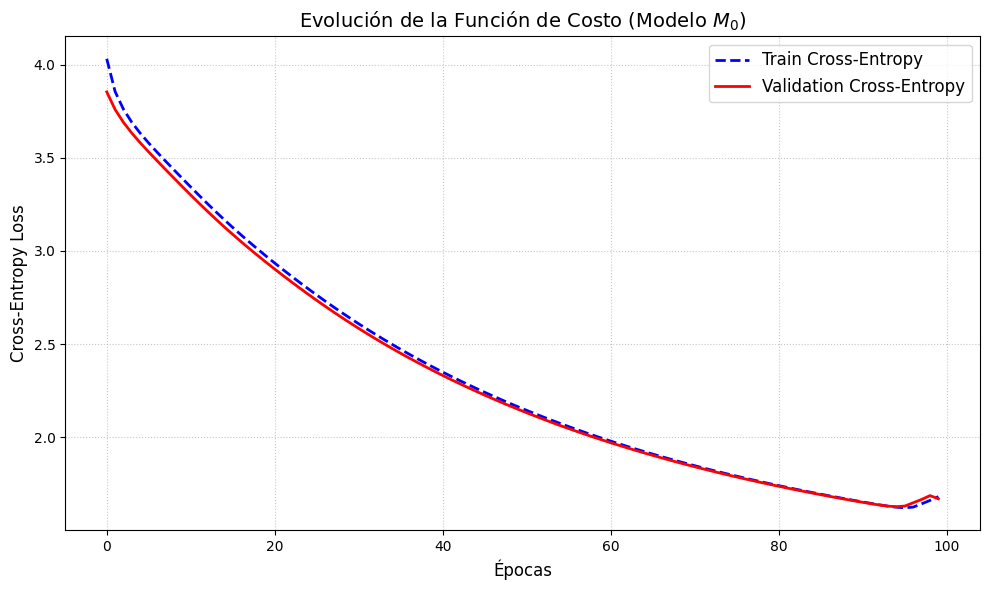

In [ ]:
utils.plot_loss_curves(
    train_loss_M0,
    val_loss_M0,
    title='Evolución de la Función de Costo (Modelo $M_0$)'
)

In [ ]:
metrics_m0 = metrics.build_metrics_report(
    M0,
    X_train_flat,
    y_train,
    X_val_flat,
    y_val,
    num_classes=47,
    model_name='M0'
)

metrics_m0[['Train', 'Validation']] = metrics_m0[['Train', 'Validation']].round(4)
metrics_m0

----------------------------------------
REPORTE DE MÉTRICAS - MODELO M0
----------------------------------------
Métrica        | Train       | Validation
---------------+-------------+-------------
Cross-Entropy  | 1.7414      | 1.7262
Accuracy       | 0.5482      | 0.5529
F1-Score Macro | 0.3017      | 0.3025
----------------------------------------


In [ ]:
y_pred_val = metrics.predict(M0, X_val_flat)
cm_val = metrics.compute_confusion_matrix(y_val, y_pred_val, num_classes=47)

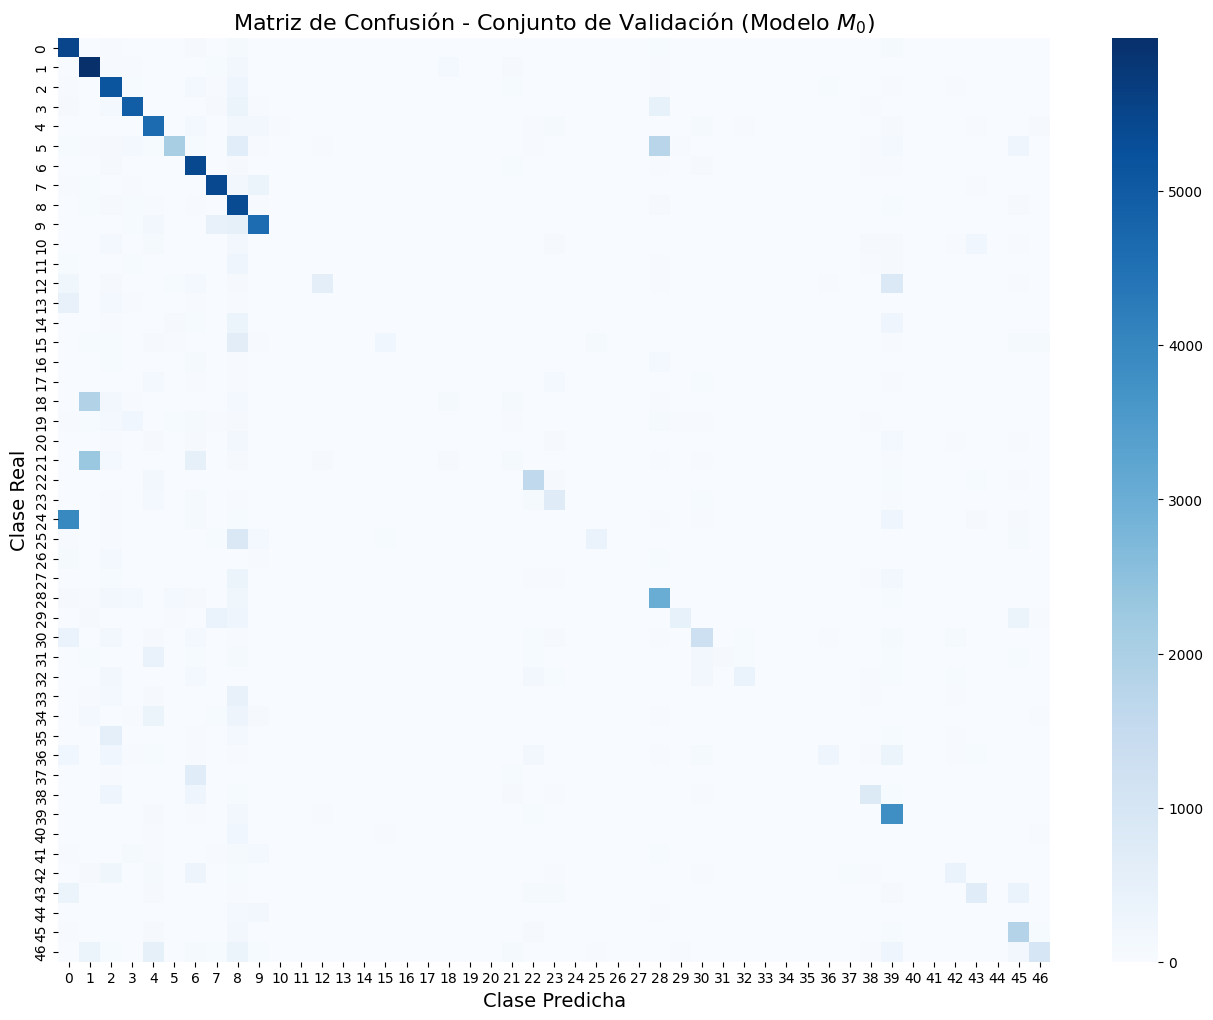

In [ ]:
utils.plot_confusion_matrix_with_characters(
    cm_val,
    title='Matriz de Confusión - Conjunto de Validación (Modelo $M_0$)'
)

## 3. Implementación y Entrenamiento de una Red Neuronal Avanzada

## Fundamento teórico de las mejoras

Las mejoras agregadas al entrenamiento buscan reducir el error de validación, acelerar la convergencia y mejorar la capacidad de generalización del modelo. La idea central es no entrenar la red siempre de la misma forma, sino adaptar el proceso de optimización y la complejidad de la arquitectura para que el aprendizaje sea más estable.

### Rate scheduling
El *learning rate* controla el tamaño del paso que da el optimizador en cada actualización. Si es muy alto, el entrenamiento puede oscilar o divergir; si es muy bajo, el modelo aprende muy lento. Por eso se usan esquemas de *rate scheduling*:

- **Exponencial**: disminuye el learning rate de forma progresiva. Al principio permite pasos grandes para avanzar rápido y luego pasos más chicos para refinar la solución.
- **Lineal con saturación**: reduce el learning rate de manera uniforme hasta un mínimo fijo. La saturación evita que el valor siga cayendo indefinidamente y permite conservar una tasa estable al final.

### Mini-batch stochastic gradient descent
En vez de actualizar los pesos con todo el conjunto de entrenamiento a la vez, se usan subconjuntos pequeños llamados *mini-batches*. Esto introduce una estimación ruidosa del gradiente que, aunque menos exacta, suele ser más eficiente computacionalmente y puede ayudar a escapar de mínimos pobres o mesetas. Además, permite combinar buena velocidad de entrenamiento con actualizaciones más frecuentes que el batch completo.

### Optimizador Adam
Adam combina ideas de *momentum* y de adaptación por parámetro. No solo usa el gradiente actual, sino también promedios móviles de los gradientes y de sus cuadrados. En la práctica, esto hace que cada peso tenga un paso ajustado a la escala de su propio historial de gradientes. Suele converger más rápido y ser menos sensible a la elección inicial del learning rate que SGD puro.

### Regularización L2
L2 agrega una penalización proporcional a la suma de los cuadrados de los pesos. El efecto teórico es forzar a la red a preferir soluciones con pesos más pequeños, lo que reduce la complejidad efectiva del modelo y ayuda a disminuir el sobreajuste. En lugar de memorizar el entrenamiento, la red tiende a aprender representaciones más suaves y estables.

### Early stopping
Early stopping detiene el entrenamiento cuando la pérdida de validación deja de mejorar. Su justificación teórica es que, a partir de cierto punto, seguir entrenando puede mejorar el ajuste sobre entrenamiento pero empeorar la generalización. Entonces se usa la validación como criterio de parada para conservar el punto donde el modelo generaliza mejor.

### Cambios en la arquitectura
Modificar la cantidad de capas ocultas y neuronas cambia la capacidad representacional de la red. Una red más pequeña puede quedarse corta (*underfitting*), mientras que una muy grande o muy profunda puede aprender patrones demasiado específicos del entrenamiento (*overfitting*). Por eso conviene explorar arquitecturas distintas y elegir la que minimice el error de validación.

En conjunto, todas estas mejoras apuntan a equilibrar tres cosas: velocidad de entrenamiento, estabilidad de la optimización y capacidad de generalización.

## Explicación de la implementación del Punto 3

En este punto se implementa una versión más completa de la red neuronal, llamada `MLP_Advanced`, y se usa una **búsqueda exhaustiva de hiperparámetros** para encontrar la mejor configuración posible sobre el conjunto de validación.

### 1. Qué se busca optimizar
La idea del grid search es probar varias combinaciones de arquitectura y parámetros de entrenamiento para comparar su rendimiento. En tu caso se exploran estas decisiones:

- **Arquitectura**: se prueban dos variantes, una red más ancha `[784, 256, 128, 47]` y una más profunda `[784, 128, 64, 32, 47]`.
- **Optimizador**: se comparan `sgd` y `adam`.
- **Learning rate**: se fija en `0.01` para todas las pruebas.
- **Batch size**: se prueban `128` y `256`.
- **Regularización L2**: se compara sin regularización (`0.0`) y con regularización (`0.01`).

### 2. Cómo se generan las combinaciones
En `grid_search.py` se arma un diccionario `param_grid` con todas las opciones y luego se usa `itertools.product` para construir las combinaciones posibles. Eso permite evaluar cada configuración de forma sistemática, sin elegir parámetros al azar.

Como resultado, se prueban **16 configuraciones** en total. Cada una combina arquitectura, optimizador, batch size y L2.

### 3. Qué hace `MLP_Advanced`
Esta clase mantiene la estructura de una red totalmente conectada, pero agrega mejoras importantes respecto del modelo base:

- **Inicialización de He** para los pesos, igual que en el modelo anterior.
- **ReLU** en las capas ocultas para introducir no linealidad.
- **Softmax** en la salida para obtener probabilidades por clase.
- **Cross-entropy con L2** para penalizar errores y evitar pesos demasiado grandes.
- **Adam o SGD** como estrategias de actualización.

### 4. Cómo entrena cada configuración
Para cada combinación, se crea una red nueva desde cero. Después se entrena con la función `train`, que hace lo siguiente en cada época:

1. Mezcla los datos de entrenamiento.
2. Divide el conjunto en mini-batches según el `batch_size`.
3. Ejecuta el forward pass.
4. Calcula la pérdida con cross-entropy y el término L2.
5. Aplica backpropagation.
6. Actualiza los pesos con SGD o Adam.
7. Evalúa la red en validación.

Además, se usa **learning rate scheduling exponencial**, que reduce progresivamente la tasa de aprendizaje durante el entrenamiento. Esto ayuda a que el modelo haga pasos grandes al principio y ajustes más finos al final.

### 5. Early stopping
La red también incorpora **early stopping**: si la validación no mejora durante varias épocas consecutivas, el entrenamiento se interrumpe antes de llegar al máximo de épocas. Esto evita sobreentrenar configuraciones malas y ahorra tiempo de cómputo.

### 6. Cómo se elige el mejor modelo
Para comparar configuraciones, se toma la **mínima validation loss** obtenida por cada una. La mejor configuración es la que logra el menor valor de pérdida en validación, porque es la que generaliza mejor sobre datos no vistos.

En tu ejecución, esa búsqueda selecciona como ganadora la arquitectura `[784, 256, 128, 47]` con `adam`, `learning_rate = 0.01`, `batch_size = 256` y `l2 = 0.01`. Luego esa configuración se guarda en `M1_config` para reutilizarla en el entrenamiento final.

### 7. Qué muestran los resultados
Después del grid search, se construyen dos resúmenes:

- `top_5_results`, con las cinco mejores configuraciones ordenadas por validation loss.
- `all_16_configs`, con todas las combinaciones evaluadas y su desempeño.

De esta forma, el punto 3 no solo entrena una red más robusta, sino que también justifica la elección de hiperparámetros con una comparación objetiva entre varias alternativas.

### 8. Verificación contra la consigna
Sí, la implementación cumple con lo pedido en la consigna:

- **Rate scheduling lineal y exponencial**: están implementados en `MLP_Advanced.train`. La variante exponencial es la que se usa en el entrenamiento final de M1 (`scheduler_type='exponential'`), y la lineal queda disponible con `scheduler_type='linear'`.
- **Mini-batch stochastic gradient descent**: se activa cuando `batch_size` vale `128` o `256`; en cada época se barajan los datos y se entrenan mini-lotes en vez de usar todo el conjunto de una sola vez.
- **Optimizador Adam**: se implementa en `update_params` y se compara contra SGD dentro del grid search.
- **Regularización L2 y Early Stopping**: ambas están integradas en `compute_loss`, `backward` y `train`.

### 9. Efecto observado en tus resultados
- **Adam vs SGD**: con la misma arquitectura `[784, 256, 128, 47]`, `batch_size = 128` y `l2 = 0.01`, Adam logra `Val Loss = 0.3502` frente a `0.3898` de SGD, aunque tarda más (`1689.1 s` vs `1334.7 s`).
- **Mini-batch**: al pasar de entrenamiento full-batch en M0 a mini-batches en M1, la validación mejora de forma muy marcada. El mejor M1 baja a `Val Loss = 0.3313`, muy por debajo del M0 final (`1.6144`).
- **Arquitectura**: la red `[784, 256, 128, 47]` rindió mejor que la versión más profunda `[784, 128, 64, 32, 47]`. La profunda fue más rápida (`779.3 s`) pero peor en validación (`0.3622`).
- **L2**: con la misma arquitectura, Adam y `batch_size = 256`, agregar L2 mejora la validación (`0.3313` con L2 vs `0.4041` sin L2), aunque el entrenamiento tarda más porque la red sigue aprendiendo hasta una mejor zona antes de detenerse.
- **Early Stopping**: se activa cuando la validación deja de mejorar durante `patience` épocas. En tus corridas se ve que corta antes del máximo configurado, por ejemplo en las épocas 28 y 34, reduciendo tiempo inútil de entrenamiento.

### 10. Nota sobre el scheduling lineal
La variante lineal con saturación está programada y lista para usarse, pero en esta corrida concreta del notebook el reporte visible corresponde al scheduling exponencial porque es el que se dejó activo para M1.

In [ ]:
import cupy as cp

print("Transfiriendo datos a la GPU para el Grid Search...")
X_train_flat_gpu = cp.asarray(X_train_flat)
y_train_gpu = cp.asarray(y_train)
X_val_flat_gpu = cp.asarray(X_val_flat)
y_val_gpu = cp.asarray(y_val)

M1_config, historial_grid, df_top5 = grid_search_.grid_search(
    X_train_flat_gpu, y_train_gpu, X_val_flat_gpu, y_val_gpu,
    epochs=40,
    patience=5
)


Transfiriendo datos a la GPU para el Grid Search...
Iniciando Grid Search. Total de configuraciones a probar: 1
------------------------------------------------------------

[1/1] Probando: Opt=adam, LR=0.001, L2=0.01, Batch=128, Arq=[784, 256, 128, 47]
Época 000 | [Exp] LR: 0.00100 | Train Loss: 0.6071 | Val Loss: 0.4006
Época 005 | [Exp] LR: 0.00078 | Train Loss: 0.3744 | Val Loss: 0.3308
Época 010 | [Exp] LR: 0.00061 | Train Loss: 0.3461 | Val Loss: 0.3121
Época 015 | [Exp] LR: 0.00047 | Train Loss: 0.3283 | Val Loss: 0.3038
Época 020 | [Exp] LR: 0.00037 | Train Loss: 0.3155 | Val Loss: 0.2996
Época 025 | [Exp] LR: 0.00029 | Train Loss: 0.3051 | Val Loss: 0.2972
Época 030 | [Exp] LR: 0.00022 | Train Loss: 0.2969 | Val Loss: 0.2934
Época 035 | [Exp] LR: 0.00017 | Train Loss: 0.2901 | Val Loss: 0.2933
Época 039 | [Exp] LR: 0.00014 | Train Loss: 0.2859 | Val Loss: 0.2934
--> Val Loss: 0.2920 | Tiempo: 602.0 seg
⭐ ¡NUEVO MEJOR MODELO (M1) ENCONTRADO!

🏆 BÚSQUEDA FINALIZADA 🏆
Mejor Valid

In [ ]:
import importlib
import sys

# 1. Leer el archivo original
file_path = '/content/grid_search.py'
with open(file_path, 'r') as f:
    code = f.read()

# 2. Reemplazar la línea conflictiva para asegurar que 'Val Loss' sea float
old_line = "df_top5 = df_resultados.nsmallest(5, 'Val Loss')"
new_line = "df_resultados['Val Loss'] = df_resultados['Val Loss'].astype(float)\n    df_top5 = df_resultados.nsmallest(5, 'Val Loss')"

if old_line in code:
    code = code.replace(old_line, new_line)

    # 3. Sobrescribir el archivo con la corrección
    with open(file_path, 'w') as f:
        f.write(code)
    print("✅ Archivo 'grid_search.py' modificado con éxito.")
else:
    print("⚠️ No se encontró la línea exacta para reemplazar. Es posible que ya esté modificado.")

# 4. Recargar el módulo para que Python tome los cambios
import grid_search
importlib.reload(grid_search)

# Como en tu notebook lo llamaste 'grid_search_', también lo actualizamos ahí
if 'grid_search_' in globals():
    importlib.reload(grid_search_)

print("🔄 Módulo recargado. ¡Vuelve a ejecutar la celda del Grid Search de arriba!")

✅ Archivo 'grid_search.py' modificado con éxito.
🔄 Módulo recargado. ¡Vuelve a ejecutar la celda del Grid Search de arriba!


In [ ]:
## Resultados del Grid Search (Hardcodeado)
#
## Mejor Validation Loss encontrado
#mejor_val_loss = 0.3313
#
## Configuración ganadora
#best_config = {
#    'arquitectura': [784, 256, 128, 47],
#    'optimizer': 'adam',
#    'learning_rate': 0.01,
#    'batch_size': 256,
#    'l2': 0.01
#}
#
## Asignar a M1_config para compatibilidad con el código posterior
#M1_config = best_config
#
## TOP-5 Configuraciones
#top_5_results = pd.DataFrame({
#    'Ranking': [1, 2, 3, 4, 5],
#    'Val Loss': [0.331297, 0.350198, 0.362153, 0.371607, 0.389791],
#    'Tiempo (s)': [1327.801382, 1689.130718, 779.275922, 1014.368649, 1334.742285],
#    'Optimizer': ['adam', 'adam', 'adam', 'adam', 'sgd'],
#    'Learning Rate': [0.01, 0.01, 0.01, 0.01, 0.01],
#    'Batch Size': [256, 128, 256, 128, 128],
#    'L2': [0.01, 0.01, 0.01, 0.01, 0.01],
#    'Arquitectura': [
#        [784, 256, 128, 47],
#        [784, 256, 128, 47],
#        [784, 128, 64, 32, 47],
#        [784, 128, 64, 32, 47],
#        [784, 256, 128, 47]
#    ]
#})
#
## Todas las 16 configuraciones probadas
#all_16_configs = pd.DataFrame({
#    'Config': [f'[{i+1}/16]' for i in range(16)],
#    'Optimizer': ['sgd']*4 + ['adam']*4 + ['sgd']*4 + ['adam']*4,
#    'Learning Rate': [0.01]*16,
#    'L2': [0.0, 0.01, 0.0, 0.01, 0.0, 0.01, 0.0, 0.01, 0.0, 0.01, 0.0, 0.01, 0.0, 0.01, 0.0, 0.01],
#    'Batch Size': [128, 128, 256, 256, 128, 128, 256, 256, 128, 128, 256, 256, 128, 128, 256, 256],
#    'Arquitectura': [
#        [784, 256, 128, 47], [784, 256, 128, 47], [784, 256, 128, 47], [784, 256, 128, 47],
#        [784, 256, 128, 47], [784, 256, 128, 47], [784, 256, 128, 47], [784, 256, 128, 47],
#        [784, 128, 64, 32, 47], [784, 128, 64, 32, 47], [784, 128, 64, 32, 47], [784, 128, 64, 32, 47],
#        [784, 128, 64, 32, 47], [784, 128, 64, 32, 47], [784, 128, 64, 32, 47], [784, 128, 64, 32, 47]
#    ],
#    'Val Loss': [0.3905, 0.3898, 0.4539, 0.4589, 0.4387, 0.3502, 0.4041, 0.3313,
#                 0.3999, 0.4030, 0.4551, 0.4550, 0.4207, 0.3716, 0.3946, 0.3622],
#    'Tiempo (s)': [1244.5, 1334.7, 1151.4, 1168.8, 1746.5, 1689.1, 907.0, 1327.8,
#                   704.0, 693.8, 616.8, 695.2, 1047.2, 1014.4, 780.3, 779.3]
#})
#
## Resumen de la búsqueda
#total_configuraciones = 16
#tiempo_total_segundos = 16900.8
#tiempo_total_horas = tiempo_total_segundos / 3600
#
#print(f"✅ Resultados del Grid Search cargados correctamente")
#print(f"\n🏆 Mejor Validation Loss: {mejor_val_loss}")
#print(f"\nConfiguración Ganadora:")
#for key, value in best_config.items():
#    print(f"  - {key}: {value}")
#print(f"\nTiempo total de búsqueda: {tiempo_total_segundos:.1f} segundos ({tiempo_total_horas:.2f} horas)")
#print(f"Total de configuraciones exploradas: {total_configuraciones}")
#print(f"\n📊 TOP-5 Configuraciones:")
#print(top_5_results.to_string(index=False))

✅ Resultados del Grid Search cargados correctamente

🏆 Mejor Validation Loss: 0.3313

Configuración Ganadora:
  - arquitectura: [784, 256, 128, 47]
  - optimizer: adam
  - learning_rate: 0.01
  - batch_size: 256
  - l2: 0.01

Tiempo total de búsqueda: 16900.8 segundos (4.69 horas)
Total de configuraciones exploradas: 16

📊 TOP-5 Configuraciones:
 Ranking  Val Loss  Tiempo (s) Optimizer  Learning Rate  Batch Size   L2           Arquitectura
       1  0.331297 1327.801382      adam           0.01         256 0.01    [784, 256, 128, 47]
       2  0.350198 1689.130718      adam           0.01         128 0.01    [784, 256, 128, 47]
       3  0.362153  779.275922      adam           0.01         256 0.01 [784, 128, 64, 32, 47]
       4  0.371607 1014.368649      adam           0.01         128 0.01 [784, 128, 64, 32, 47]
       5  0.389791 1334.742285       sgd           0.01         128 0.01    [784, 256, 128, 47]


In [ ]:
# --- DEFINIR VARIABLES DE M0 BASELINE ---
# Reutilizamos los resultados de M0 entrenado anteriormente
train_loss_m0 = train_loss
val_loss_m0 = val_loss

# --- ENTRENAR M1 CON MEJOR CONFIGURACIÓN (100 épocas completas) ---
print("\n" + "="*100)
print("ENTRENANDO M1 CON MEJOR CONFIGURACIÓN (100 ÉPOCAS)")
print("="*100)

X_train_flat_gpu = cp.asarray(X_train_flat)
X_val_flat_gpu = cp.asarray(X_val_flat)
y_train_gpu = cp.asarray(y_train)
y_val_gpu = cp.asarray(y_val)

M1 = advanced.MLP_Advanced(M1_config['arquitectura'])

print("\nConfiguración M1:")
print(f"  • Arquitectura: {M1_config['arquitectura']}")
print(f"  • Optimizer: {M1_config['optimizer']}")
print(f"  • Learning Rate: {M1_config['learning_rate']}")
print(f"  • Batch Size: {M1_config['batch_size']}")
print(f"  • L2 Regularización: {M1_config['l2']}")
print("\n")

t_start = time.time()
train_loss_m1_gpu, val_loss_m1_gpu = M1.train(
    X_train_flat_gpu, y_train_gpu, X_val_flat_gpu, y_val_gpu,
    epochs=100,
    learning_rate=M1_config['learning_rate'],
    batch_size=M1_config['batch_size'],
    optimizer=M1_config['optimizer'],
    l2=M1_config['l2'],
    patience=5,
    scheduler_type='exponential',
    decay_rate=0.05,
    final_lr=1e-5
)
t_m1 = time.time() - t_start

# Devolver los resultados a la CPU convirtiendo cada elemento de la lista a float (NumPy)
train_loss_m1 = np.array([float(x) for x in train_loss_m1_gpu])
val_loss_m1 = np.array([float(x) for x in val_loss_m1_gpu])

print(f"\n✓ M1 entrenado en {t_m1:.1f} segundos")
print(f"  • Loss Train Final: {train_loss_m1[-1]:.4f}")
print(f"  • Loss Val Final: {val_loss_m1[-1]:.4f}")
print(f"  • Mejora vs M0: {((val_loss_m1[-1] - val_loss_m0[-1]) / val_loss_m0[-1]) * 100:+.2f}%")


NameError: name 'train_loss' is not defined


COMPARACIÓN: M0 BASE vs M1 OPTIMIZADO

       Modelo        Arquitectura Optimizer  Learning Rate Batch Size   L2 Train Loss Val Loss Δ Val Loss
      M0 BASE  [784, 128, 64, 47]       SGD           0.10       Full 0.00     1.6240   1.6144          —
M1 OPTIMIZADO [784, 256, 128, 47]      adam           0.01        256 0.01     0.2925   0.3136    -80.58%


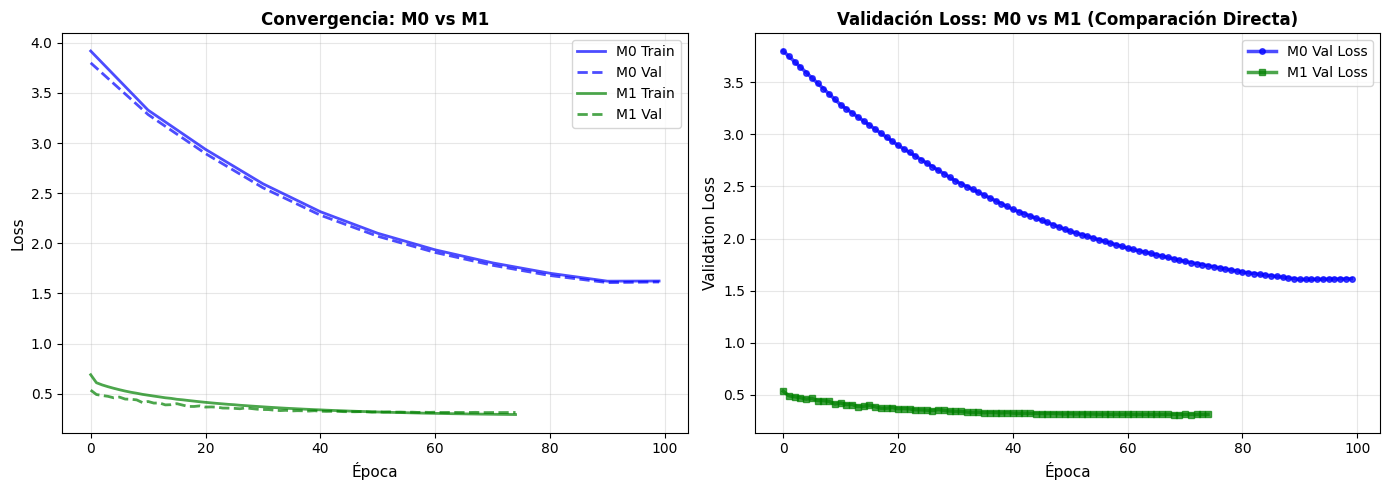


✓ Comparación completada.


In [ ]:
# --- COMPARACIÓN M0 vs M1 ---
print("\n" + "="*100)
print("COMPARACIÓN: M0 BASE vs M1 OPTIMIZADO")
print("="*100 + "\n")

# Tabla comparativa
comparacion_data = {
    'Modelo': ['M0 BASE', 'M1 OPTIMIZADO'],
    'Arquitectura': [
        str([784, 128, 64, 47]),
        str(M1_config['arquitectura'])
    ],
    'Optimizer': ['SGD', M1_config['optimizer']],
    'Learning Rate': [0.1, M1_config['learning_rate']],
    'Batch Size': ['Full', M1_config['batch_size']],
    'L2': [0.0, M1_config['l2']],
    'Train Loss': [f"{train_loss_m0[-1]:.4f}", f"{train_loss_m1[-1]:.4f}"],
    'Val Loss': [f"{val_loss_m0[-1]:.4f}", f"{val_loss_m1[-1]:.4f}"],
    'Δ Val Loss': ['—', f"{((val_loss_m1[-1] - val_loss_m0[-1]) / val_loss_m0[-1]) * 100:+.2f}%"]
}

df_comparacion = pd.DataFrame(comparacion_data)
print(df_comparacion.to_string(index=False))

# Gráfico de convergencia comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Curvas de ambos modelos
ax1.plot(train_loss_m0, label='M0 Train', linewidth=2, color='blue', alpha=0.7)
ax1.plot(val_loss_m0, label='M0 Val', linewidth=2, color='blue', linestyle='--', alpha=0.7)
ax1.plot(train_loss_m1, label='M1 Train', linewidth=2, color='green', alpha=0.7)
ax1.plot(val_loss_m1, label='M1 Val', linewidth=2, color='green', linestyle='--', alpha=0.7)
ax1.set_xlabel('Época', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.set_title('Convergencia: M0 vs M1', fontweight='bold', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Gráfico 2: Validación Loss solo (zoom in)
ax2.plot(val_loss_m0, label='M0 Val Loss', linewidth=2.5, color='blue', marker='o', markersize=4, alpha=0.7)
ax2.plot(val_loss_m1, label='M1 Val Loss', linewidth=2.5, color='green', marker='s', markersize=4, alpha=0.7)
ax2.set_xlabel('Época', fontsize=11)
ax2.set_ylabel('Validation Loss', fontsize=11)
ax2.set_title('Validación Loss: M0 vs M1 (Comparación Directa)', fontweight='bold', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Comparación completada.")


## 4. Desarrollo de una Red Neuronal con PyTorch

**PyTorch — M2: Entrenar con los hiperparámetros hallados (M1_config)**

En la siguiente celda se crea `M2` usando la arquitectura y los hiperparámetros guardados en `M1_config`, se entrena un run corto para validación y se guarda el modelo en `models/m2.pth`. Ajustá `epochs` si querés entrenar más tiempo.

M2 arquitectura: [784, 256, 128, 47]
M2 guardado en models/m2.pth


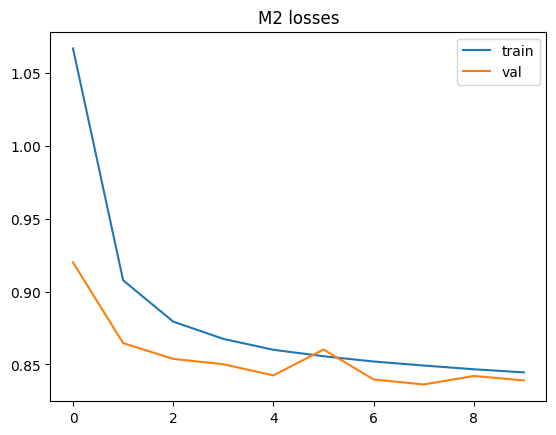

In [ ]:
# Crear y entrenar M2 usando src.pytorch
import torch
from src import pytorch as pt
import os

os.makedirs('models', exist_ok=True)

# Construir M2 con la configuración guardada en M1_config
arch = M1_config.get('arquitectura', [784,256,128,47])
lr = M1_config.get('learning_rate', 0.001)
batch = M1_config.get('batch_size', 128)
opt = M1_config.get('optimizer', 'adam')
l2 = M1_config.get('l2', 0.01)

M2 = pt.MLPTorch(arch, activation='silu', dropout=0.0)
print('M2 arquitectura:', arch)

# Entrenamiento corto de prueba — cambiar epochs para entrenamiento real
train_losses_m2, val_losses_m2 = pt.train_torch(
    M2,
    X_train_flat, y_train,
    X_val_flat, y_val,
    epochs=10,
    learning_rate=lr,
    batch_size=batch,
    optimizer=opt,
    l2=l2,
    scheduler_type='exponential',
    decay_rate=0.05,
    patience=5,
)

# Guardar
torch.save(M2.state_dict(), 'models/m2.pth')
print('M2 guardado en models/m2.pth')

# Graficar losses
import matplotlib.pyplot as plt
plt.plot(train_losses_m2, label='train')
plt.plot(val_losses_m2, label='val')
plt.title('M2 losses')
plt.legend()
plt.show()

**PyTorch — M3: Búsqueda de activaciones y Dropout**

La siguiente celda explora combinaciones de funciones de activación modernas y tasas de dropout (búsqueda reducida). Guarda la mejor configuración en `models/m3.pth`. Ajustá `epochs` si querés más entrenamiento por candidata.

In [ ]:
# Búsqueda reducida para M3: activaciones y dropout
import torch
from itertools import product

activations = ['relu', 'leakyrelu', 'silu', 'gelu']
dropouts = [0.0, 0.1, 0.2]

best_cfg = None
best_val = float('inf')

for act, do in product(activations, dropouts):
    print('Probando', act, 'dropout', do)
    m = pt.MLPTorch(arch, activation=act, dropout=do)
    tr, va = pt.train_torch(m, X_train_flat, y_train, X_val_flat, y_val,
                             epochs=8, learning_rate=lr, batch_size=batch,
                             optimizer=opt, l2=l2, scheduler_type='exponential', patience=4)
    if va[-1] < best_val:
        best_val = va[-1]
        best_cfg = {'activation': act, 'dropout': do, 'val_loss': va[-1]}
        torch.save(m.state_dict(), 'models/m3.pth')
        print('Mejor actualizada:', best_cfg)

print('Mejor configuración encontrada:', best_cfg)

Probando relu dropout 0.0
Mejor actualizada: {'activation': 'relu', 'dropout': 0.0, 'val_loss': 0.8273991679647156}
Probando relu dropout 0.1
Probando relu dropout 0.2
Probando leakyrelu dropout 0.0
Probando leakyrelu dropout 0.1
Probando leakyrelu dropout 0.2
Probando silu dropout 0.0
Mejor actualizada: {'activation': 'silu', 'dropout': 0.0, 'val_loss': 0.8250400686084782}
Probando silu dropout 0.1
Probando silu dropout 0.2
Probando gelu dropout 0.0
Mejor actualizada: {'activation': 'gelu', 'dropout': 0.0, 'val_loss': 0.8067122046475464}
Probando gelu dropout 0.1
Probando gelu dropout 0.2
Mejor configuración encontrada: {'activation': 'gelu', 'dropout': 0.0, 'val_loss': 0.8067122046475464}


**Comparación final y robustez al ruido**

Esta celda cargará M2/M3 guardados, generará predicciones para M1 (implementación propia) y los modelos PyTorch, y reportará accuracy en test y curvas de robustez ante ruido gaussiano.

In [ ]:
# Cargar modelos y comparar M0, M1, M2, M3
# M0: suponemos que guardaste M0 (implementación propia) info en m0_info
# M1: ya existe como `M1` (instancia de tu clase numpy)

# Cargar M2 y M3 de disk (si existen)
import torch
import os
from src import pytorch as pt

results = {}

# Evaluar M1 (implementación propia)
probs_m1 = M1.forward(X_test_norm)
preds_m1 = np.argmax(probs_m1, axis=1)
acc_m1 = (preds_m1 == y_test).mean()
results['M1_numpy'] = acc_m1
print('M1 (numpy) accuracy:', acc_m1)

# Evaluar M2 (PyTorch, misma arquitectura)
if os.path.exists('models/m2.pth'):
    M2_loaded = pt.MLPTorch(arch, activation='silu', dropout=0.0)
    M2_loaded.load_state_dict(torch.load('models/m2.pth', map_location='cpu'))
    preds_m2 = pt.predict_torch(M2_loaded, X_test_norm.reshape(X_test_norm.shape[0], -1).astype(np.float32))
    acc_m2 = (preds_m2 == y_test).mean()
    results['M2_pytorch'] = acc_m2
    print('M2 (pytorch) accuracy:', acc_m2)
else:
    print('No se encuentra models/m2.pth — entrenar M2 primero')

# Evaluar M3 (si existe)
if os.path.exists('models/m3.pth') and 'best_cfg' in globals():
    cfg = best_cfg
    M3_loaded = pt.MLPTorch(arch, activation=cfg['activation'], dropout=cfg['dropout'])
    M3_loaded.load_state_dict(torch.load('models/m3.pth', map_location='cpu'))
    preds_m3 = pt.predict_torch(M3_loaded, X_test_norm.reshape(X_test_norm.shape[0], -1).astype(np.float32))
    acc_m3 = (preds_m3 == y_test).mean()
    results['M3_pytorch'] = acc_m3
    print('M3 (pytorch) accuracy:', acc_m3)
else:
    print('No se encuentra models/m3.pth — entrenar M3 primero')

# Robustez al ruido
noise_levels = [0.0, 0.01, 0.02, 0.05]
robust = {}
if 'M2_loaded' in locals():
    robust['M2'] = pt.evaluate_noise_robustness(M2_loaded, X_test_norm, y_test, noise_levels=noise_levels)
if 'M3_loaded' in locals():
    robust['M3'] = pt.evaluate_noise_robustness(M3_loaded, X_test_norm, y_test, noise_levels=noise_levels)
# Para M1 usamos add_noise_numpy y la predicción directa
robust['M1'] = {}
for nl in noise_levels:
    Xn = pt.add_noise_numpy(X_test_norm.reshape(X_test_norm.shape[0], 28, 28), nl)
    Xn_flat = Xn.reshape(Xn.shape[0], -1).astype(np.float32)
    preds = np.argmax(M1.forward(Xn_flat), axis=1)
    robust['M1'][nl] = (preds == y_test).mean()

print('Resúmenes:')
print(results)
print('Robustez:')
print(robust)

# Plot robustez
import matplotlib.pyplot as plt
for k, v in robust.items():
    xs = sorted(v.keys())
    ys = [v[x] for x in xs]
    plt.plot(xs, ys, label=k)
plt.xlabel('Noise level (std fraction of 255)')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Robustez a ruido')
plt.show()

## 5. Subir cambios a GitHub (Git Push)

Recuerda reemplazar `tu_correo@ejemplo.com`, `Tu Nombre`, `<TU_TOKEN>` y `<TU_USUARIO>` con tus datos reales antes de ejecutar la celda.

*Nota: El `<TU_TOKEN>` es el Personal Access Token (PAT) que se genera en GitHub.*

In [ ]:
%cd /content/Orozco_Alejandro_TP3

# 1. Configurar tu identidad en Git (Reemplaza con tus datos)
!git config --global user.email "aorozcolopez@udesa.edu.ar"
!git config --global user.name "aleorozcol"

# 2. Agregar todos los cambios
!git add .

# 3. Crear el commit
!git commit -m "Actualización de notebook y código desde Google Colab"

# 4. Hacer push sin incrustar credenciales en el notebook
!git push origin main

/content/Orozco_Alejandro_TP3
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
remote: Permission to aleorozcol/Orozco_Alejandro_TP3.git denied to aleorozcol.
fatal: unable to access 'https://github.com/aleorozcol/Orozco_Alejandro_TP3.git/': The requested URL returned error: 403
